**生成式AI的使用**：对于本作业，生成式AI的使用同样受限于关于合作的相关政策。就像与其他合作者一样，每位学生必须独立于交互输出写下答案，并且提交时应包含说明合作性质的备注。使用生成式AI工具来完成作业的大部分内容不符合本作业的精神，并会被视为违反[荣誉代码(Honor Code)](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)。

**学生声明（必须完成）**

**SUNet id:**  
_你的 SUNet id_

**你是否使用了生成式AI工具（例如 ChatGPT, Copilot 等）？**  
- [ ] 否  
- [ ] 是（请在下方描述）

**如果是，请描述你如何使用生成式AI，以及用于作业的哪些部分：**  
_你的回答_

**确认所有提交的工作都反映了你自己的理解，并且你没有依赖AI来完成作业的大部分内容：**  
- [ ] 我确认

In [1]:
# 这会将你的 Google Drive 挂载到 Colab 虚拟机上。
#from google.colab import drive
#drive.mount('/content/drive')

# TODO: 输入你保存在 Drive 中解压后的作业文件夹名称
# 例如 'cs231n/assignments/assignment3/'
#FOLDERNAME = 'cs231n/assignments/assignment3/'
#assert FOLDERNAME is not None, "[!] Enter the foldername."

# 既然我们已经挂载了你的 Drive，这确保了
# Colab 虚拟机的 Python 解释器可以从中加载
# Python 文件。
#import sys
#sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# 如果 COCO 数据集尚不存在，这会将其下载
# 到你的 Drive 中。
#%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
# !bash get_datasets.sh
#!bash get_coco_dataset.sh
#%cd /content/drive/My\ Drive/$FOLDERNAME


# 使用 Transformer 进行图像描述生成
你现在已经实现了一个用于图像描述生成任务的基础 RNN。在这个 notebook 中，你将实现 transformer 解码器的关键部分来完成相同的任务。

**注意**：与 RNN notebook 不同，这个 notebook 将主要使用 PyTorch 而不是 NumPy 编写。

In [2]:
# 设置单元格。
import time, os, json
import numpy as np
import matplotlib.pyplot as plt
import sys
import types
import importlib

from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.transformer_layers import *
from cs231n.captioning_solver_transformer import CaptioningSolverTransformer
from cs231n.classifiers.transformer import CaptioningTransformer
from cs231n.coco_utils import load_coco_data, sample_coco_minibatch, decode_captions
from cs231n.image_utils import image_from_url

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # 设置图表的默认大小。
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

if "imp" not in sys.modules:
    imp = types.ModuleType("imp")
    imp.reload = importlib.reload
    sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """ 返回相对误差 """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

# COCO 数据集
与之前的 notebook 一样，我们将使用 COCO 数据集进行图像描述生成。

In [3]:
# 从磁盘加载 COCO 数据到字典中。
data = load_coco_data(pca_features=True)

# 打印出数据字典中的所有键和值。
for k, v in data.items():
    if type(v) == np.ndarray:
        print(k, type(v), v.shape, v.dtype)
    else:
        print(k, type(v), len(v))

base dir  D:\Python\west2AI\LYFshota.me\cs231n-Assignment 3-25\assignment3\cs231n\datasets/coco_captioning
train_captions <class 'numpy.ndarray'> (400135, 17) int32
train_image_idxs <class 'numpy.ndarray'> (400135,) int32
val_captions <class 'numpy.ndarray'> (195954, 17) int32
val_image_idxs <class 'numpy.ndarray'> (195954,) int32
train_features <class 'numpy.ndarray'> (82783, 512) float32
val_features <class 'numpy.ndarray'> (40504, 512) float32
idx_to_word <class 'list'> 1004
word_to_idx <class 'dict'> 1004
train_urls <class 'numpy.ndarray'> (82783,) <U63
val_urls <class 'numpy.ndarray'> (40504,) <U63


# Transformer
如你所见，RNN 极其强大，但训练速度往往很慢。此外，RNN 在编码长距离依赖关系时会遇到困难（尽管 LSTM 是一种缓解该问题的方法）。在 2017 年，Vaswani 等人在他们的论文 ["Attention Is All You Need"](https://arxiv.org/abs/1706.03762) 中引入了 Transformer，以 a) 引入并行性并 b) 允许模型学习长距离依赖关系。这篇论文不仅在自然语言处理社区催生了诸如 BERT 和 GPT 这样著名的模型，还引发了跨领域的极大兴趣，包括计算机视觉。虽然我们在这里是在图像描述生成的背景下介绍这个模型，但注意力（attention）这个概念本身要通用得多。



# Transformer：多头注意力 (Multi-Headed Attention)

### 点积注意力 (Dot-Product Attention)

回顾一下，注意力机制可以看作是在一个查询向量 $q\in\mathbb{R}^d$、一组值向量 $\{v_1,\dots,v_n\}, v_i\in\mathbb{R}^d$ 和一组键向量 $\{k_1,\dots,k_n\}, k_i \in \mathbb{R}^d$ 上的操作，具体定义如下：

\begin{align}
c &= \sum_{i=1}^{n} v_i \alpha_i \\
\alpha_i &= \frac{\exp(k_i^\top q)}{\sum_{j=1}^{n} \exp(k_j^\top q)} \\
\end{align}

其中 $\alpha_i$ 通常被称为“注意力权重（attention weights）”，输出 $c\in\mathbb{R}^d$ 是值向量的相应加权平均值。

### 自注意力 (Self-Attention)
在 Transformer 中，我们执行自注意力机制，这意味着值、键和查询都是从输入 $X \in \mathbb{R}^{\ell \times d}$ 导出的，其中 $\ell$ 是我们的序列长度。具体来说，我们学习参数矩阵 $V,K,Q \in \mathbb{R}^{d\times d}$ 来将我们的输入 $X$ 映射如下：

\begin{align}
v_i = Vx_i\ \ i \in \{1,\dots,\ell\}\\
k_i = Kx_i\ \ i \in \{1,\dots,\ell\}\\
q_i = Qx_i\ \ i \in \{1,\dots,\ell\}
\end{align}

### 多头缩放点积注意力 (Multi-Headed Scaled Dot-Product Attention)
在多头注意力的情形下，我们为每个“头”学习一个参数矩阵，这使得模型具有更强的表达能力，去关注输入的不同部分。设 $h$ 为头的数量，$Y_i$ 为第 $i$ 个头的注意力输出。因此，我们学习独立的矩阵 $Q_i$、$K_i$ 和 $V_i$。为了保持我们的总计算量与单头情况相同，我们选择 $Q_i \in \mathbb{R}^{d\times d/h}$、$K_i \in \mathbb{R}^{d\times d/h}$ 和 $V_i \in \mathbb{R}^{d\times d/h}$。在上面简单的点积注意力中加入缩放项 $\frac{1}{\sqrt{d/h}}$，我们得到：

\begin{equation}
Y_i = \text{softmax}\bigg(\frac{(XQ_i)(XK_i)^\top}{\sqrt{d/h}}\bigg)(XV_i)
\end{equation}

其中 $Y_i\in\mathbb{R}^{\ell \times d/h}$，$\ell$ 为序列长度。

在我们的实现中，我们对注意力权重应用了 dropout（尽管在实践中它可以用在任何步骤）：

\begin{equation}
Y_i = \text{dropout}\bigg(\text{softmax}\bigg(\frac{(XQ_i)(XK_i)^\top}{\sqrt{d/h}}\bigg)\bigg)(XV_i)
\end{equation}

最后，自注意力机制的输出是将各个头的输出拼接后进行的线性变换：

\begin{equation}
Y = [Y_1;\dots;Y_h]A
\end{equation}

其中 $A \in\mathbb{R}^{d\times d}$，且 $[Y_1;\dots;Y_h]\in\mathbb{R}^{\ell \times d}$。

在 `cs231n/transformer_layers.py` 文件中的 `MultiHeadAttention` 类中实现多头缩放点积注意力。下面的代码将检查你的实现。相对误差应小于 `7e-3`。

In [4]:
torch.manual_seed(231)

# 选择所有的维度为唯一值，以便于调试：
# 具体而言，以下值对应 N=1, H=2, T=3, E//H=4, 以及 E=8。
batch_size = 1
sequence_length = 3
embed_dim = 8
attn = MultiHeadAttention(embed_dim, num_heads=2)
attn.eval()

# 自注意力 (Self-attention)。
data = torch.randn(batch_size, sequence_length, embed_dim)
self_attn_output = attn(query=data, key=data, value=data)

# 掩码自注意力 (Masked self-attention)。
mask = torch.randn(sequence_length, sequence_length) < 0.5
masked_self_attn_output = attn(query=data, key=data, value=data, attn_mask=mask)

# 使用两个输入的注意力。
other_data = torch.randn(batch_size, sequence_length, embed_dim)
attn_output = attn(query=data, key=other_data, value=other_data)

expected_self_attn_output = np.asarray([[
    [-0.1030,  0.2090,  0.7481, -0.4116, -0.2772,  0.2357, -0.2740, -0.2798],
    [-0.1794,  0.1637,  0.6930, -0.3435, -0.2300,  0.2457, -0.2504, -0.2323],
    [-0.1861,  0.1567,  0.6677, -0.3078, -0.2731,  0.2302, -0.2714, -0.2082]]])

expected_masked_self_attn_output = np.asarray([[
    [-0.1209,  0.1806,  0.8056, -0.4654, -0.2262,  0.2552, -0.2544, -0.2812],
    [-0.2374,  0.1183,  0.7423, -0.3777, -0.1460,  0.2716, -0.2213, -0.2077],
    [-0.0851,  0.2423,  0.7941, -0.3778, -0.4924,  0.1512, -0.4241, -0.1740]]])

expected_attn_output = np.asarray([[
    [-0.1965,  0.0702,  0.5227, -0.1388, -0.3530,  0.2163, -0.2643, -0.1902],
    [-0.3592, -0.0899,  0.5836,  0.0029, -0.3643,  0.2667, -0.1973, -0.1698],
    [-0.3795,  0.0433,  0.5634, -0.0749, -0.4379,  0.2714, -0.2207, -0.1980]]])

print('self_attn_output error: ', rel_error(expected_self_attn_output, self_attn_output.detach().numpy()))
print('masked_self_attn_output error: ', rel_error(expected_masked_self_attn_output, masked_self_attn_output.detach().numpy()))
print('attn_output error: ', rel_error(expected_attn_output, attn_output.detach().numpy()))

self_attn_output error:  0.0001792071437561575
masked_self_attn_output error:  9.809519326315612e-05
attn_output error:  0.006226898176165351


# 位置编码 (Positional Encoding)

虽然 transformer 能够轻松地注意到其输入的任何部分，但注意力机制本身并没有 token 顺序的概念。然而，对于许多任务（尤其是自然语言处理），相对的 token 顺序非常重要。为了恢复这一点，作者在单个词 token 的嵌入向量中加入了位置编码。

让我们定义一个矩阵 $P \in \mathbb{R}^{l\times d}$，其中 $P_{ij} = $

$$
\begin{cases}
\text{sin}\left(i \cdot 10000^{-\frac{j}{d}}\right) & \text{if j is even} \\
\text{cos}\left(i \cdot 10000^{-\frac{(j-1)}{d}}\right) & \text{otherwise} \\
\end{cases}
$$

我们不直接将输入 $X \in \mathbb{R}^{l\times d}$ 传递给网络，而是传递 $X + P$。

在 `cs231n/transformer_layers.py` 中的 `PositionalEncoding` 里实现这一层。完成后，运行以下代码对你的实现执行简单测试。你应该看到误差在 `e-3` 或更小的数量级。

In [5]:
torch.manual_seed(231)

batch_size = 1
sequence_length = 2
embed_dim = 6
data = torch.randn(batch_size, sequence_length, embed_dim)

pos_encoder = PositionalEncoding(embed_dim)
pos_encoder.eval()
output = pos_encoder(data)

expected_pe_output = np.asarray([[[-1.1106,  1.0014,  1.5280, -0.0778, -0.6964,  1.1455],
                                  [ 0.8125, -0.4303,  0.4981,  0.7320,  1.1380,  1.5331]]])
print('pe_output error: ', rel_error(expected_pe_output, output.detach().numpy()))

pe_output error:  0.00021699471301977143


# 内联问题 1

在设计我们上面介绍的缩放点积注意力时，做出了几个关键的设计决策。请解释为什么以下选择是有益的：
1. 使用多个注意力头而不是一个。
2. 在应用 softmax 函数之前除以 $\sqrt{d/h}$。回想一下 $d$ 是特征维度，$h$ 是头的数量。
3. 在注意力操作的输出端添加线性变换。

对于每个选择，只需要一两句话的解释，但请务必具体说明：如果没有给定实现细节会发生什么，为什么这样的情况是不理想的，以及所提出的实现是如何改善这种情况的。

**你的回答：**
1.如果只用一个注意力头的话，模型只能捕捉到一种类型的对应关系，多注意力头可以让模型关注到不同的特征信息。
2.如果不除的话，随着维度的增大，Q和K的点积值会变得很大，导致softmax输出会偏离，梯度消失，无法训练模型。除以维度的平方根之后可以让数值控制在一定范围内。
3.如果没有添加线性变换，只是把输出拼接在一起的话，模型就没办法在这层学习到不同注意力头提取到的特征之间的相互关系。

# Transformer 解码器块 (Transformer Decoder Block)

Transformer 解码器层由三个模块组成：(1) 自注意力，用于处理向量的输入序列；(2) 交叉注意力，用于根据可用上下文（即我们例子中的图像特征）进行处理；(3) 前馈模块，用于独立处理序列的每个向量。在 `cs231n/transformer_layers.py` 中完成 `TransformerDecoderLayer` 的实现并在下方进行测试。相对误差应该小于 1e-6。

Transformer 解码器层具有三个主要组件：(1) 一个自注意力模块，用于处理输入向量序列；(2) 一个交叉注意力模块，用于整合额外的上下文（例如，在我们的案例中是图像特征）；以及 (3) 一个前馈模块，独立地处理序列中的每个向量。在 `cs231n/transformer_layers.py` 中完成 `TransformerDecoderLayer` 的实现，并在下面进行测试。相对误差应小于 1e-6。

In [6]:
torch.manual_seed(231)
np.random.seed(231)

N, T, TM, D = 1, 4, 5, 12

decoder_layer = TransformerDecoderLayer(D, 2, 4*D)
decoder_layer.eval()
tgt = torch.randn(N, T, D)
memory = torch.randn(N, TM, D)
tgt_mask = torch.randn(T, T) < 0.5

output = decoder_layer(tgt, memory, tgt_mask)

expected_output = np.asarray([
    [[ 0.27005595, -0.21056601,  0.63376445, -0.35391954,  0.60071295,
      -1.7566615,  -0.1314159,  -1.7659538,  -0.5575517,   0.680143,
       1.8622686,   0.7291234],
     [-0.6080135,   0.4421802,  -0.07590749, -0.12093157,  0.94722354,
      -1.0223433,   0.47332686, -1.3958666,   2.1890075,  -1.0380646,
       0.9437816,  -0.7343922],
     [-0.89690155,  0.60447216,  0.10688882,  0.03492759,  1.8388084,
      -0.9772293,   0.7621334,  -0.668234,    1.3260399,  -1.8417019,
       0.21718435, -0.506388],
     [-0.70961505, -0.02918372, -0.39894593, -0.8069395,   0.04967685,
       0.29345992,  0.7871747,  -1.3172938,   1.4744806,   1.2633642,
       1.1611108,  -1.767289]]
])
print('error: ', rel_error(expected_output, output.detach().numpy()))

error:  1.5224654802442538e-06


# 用于图像描述生成的 Transformer
现在你已经实现了之前的层，你可以将它们组合起来构建一个基于 Transformer 的图像描述生成模型。打开 `cs231n/classifiers/transformer.py` 文件并查看 `CaptioningTransformer` 类。

实现该类的 `forward` 函数。完成后，运行以下代码使用一个小测试用例检查你的前向传播；你应该看到误差在 `e-5` 或更小的数量级。

In [8]:
torch.manual_seed(231)
np.random.seed(231)

N, D, W = 4, 20, 30
word_to_idx = {'<NULL>': 0, 'cat': 2, 'dog': 3}
V = len(word_to_idx)
T = 3

transformer = CaptioningTransformer(
    word_to_idx,
    input_dim=D,
    wordvec_dim=W,
    num_heads=2,
    num_layers=2,
    max_length=30
)
transformer.eval()

features = torch.randn(N, D)
captions = torch.randint(0, V, (N, T))

scores = transformer(features, captions)

expected_scores = np.asarray([
    [[ 0.62165695, -0.6203744,  -1.116114  ],
     [ 0.6641097,  -0.60309553, -1.3479083 ],
     [ 0.62117404, -0.79205745, -1.1095243 ]],
    [[ 0.62160987, -0.6214724,  -1.1171186 ],
     [ 0.6093992,  -0.61166143, -1.3365762 ],
     [ 0.62108713, -0.79322916, -1.1104958 ]],
    [[ 0.6406587,  -0.57419956, -1.1300566 ],
     [ 0.6075228,  -0.60872054, -1.3372457 ],
     [ 0.6471472,  -0.8270494,  -1.1064028 ]],
    [[ 0.64029807, -0.5755552,  -1.1284486 ],
     [ 0.60708034, -0.6099963,  -1.3356377 ],
     [ 0.59367496, -0.8346836,  -1.0914496 ]]
])

print('scores error: ', rel_error(expected_scores, scores.detach().numpy()))

scores error:  2.108501834260506e-07


# 在小数据上过拟合 Transformer 描述生成模型
运行以下代码，在与我们之前用于 RNN 的相同小数据集上对基于 Transformer 的描述生成模型进行过拟合。

base dir  D:\Python\west2AI\LYFshota.me\cs231n-Assignment 3-25\assignment3\cs231n\datasets/coco_captioning
(Iteration 1 / 200) loss: 5.045327
(Iteration 11 / 200) loss: 2.808727
(Iteration 21 / 200) loss: 2.022354
(Iteration 31 / 200) loss: 1.670440
(Iteration 41 / 200) loss: 1.330231
(Iteration 51 / 200) loss: 1.236568
(Iteration 61 / 200) loss: 0.843830
(Iteration 71 / 200) loss: 0.702294
(Iteration 81 / 200) loss: 0.516776
(Iteration 91 / 200) loss: 0.438581
(Iteration 101 / 200) loss: 0.376332
(Iteration 111 / 200) loss: 0.153824
(Iteration 121 / 200) loss: 0.139355
(Iteration 131 / 200) loss: 0.104465
(Iteration 141 / 200) loss: 0.084864
(Iteration 151 / 200) loss: 0.087970
(Iteration 161 / 200) loss: 0.053218
(Iteration 171 / 200) loss: 0.046330
(Iteration 181 / 200) loss: 0.043136
(Iteration 191 / 200) loss: 0.027111


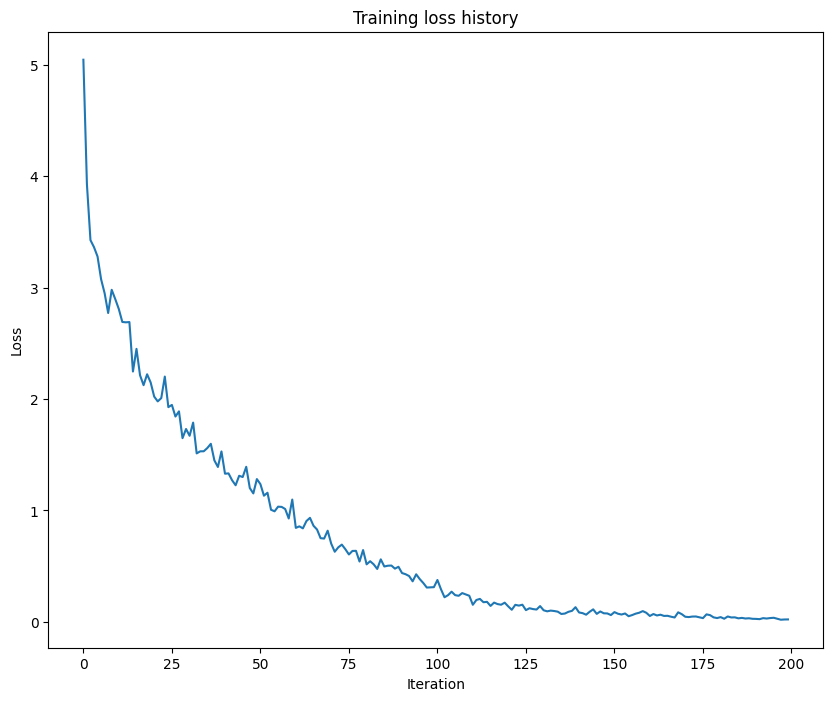

In [9]:
torch.manual_seed(231)
np.random.seed(231)

data = load_coco_data(max_train=50)

transformer = CaptioningTransformer(
          word_to_idx=data['word_to_idx'],
          input_dim=data['train_features'].shape[1],
          wordvec_dim=256,
          num_heads=2,
          num_layers=2,
          max_length=30
        )


transformer_solver = CaptioningSolverTransformer(transformer, data, idx_to_word=data['idx_to_word'],
           num_epochs=100,
           batch_size=25,
           learning_rate=0.001,
           verbose=True, print_every=10,
         )

transformer_solver.train()

# 绘制训练损失图。
plt.plot(transformer_solver.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training loss history')
plt.show()

打印最终的训练损失。你应该看到最终损失小于 0.05。

In [10]:
print('Final loss: ', transformer_solver.loss_history[-1])

Final loss:  0.022365794


# 测试时的 Transformer 采样
采样代码已经为你写好了。你只需运行以下代码即可与之前 RNN 的结果进行比较。和以前一样，考虑到我们训练的数据非常少，训练集的结果应该比验证集的结果好得多。

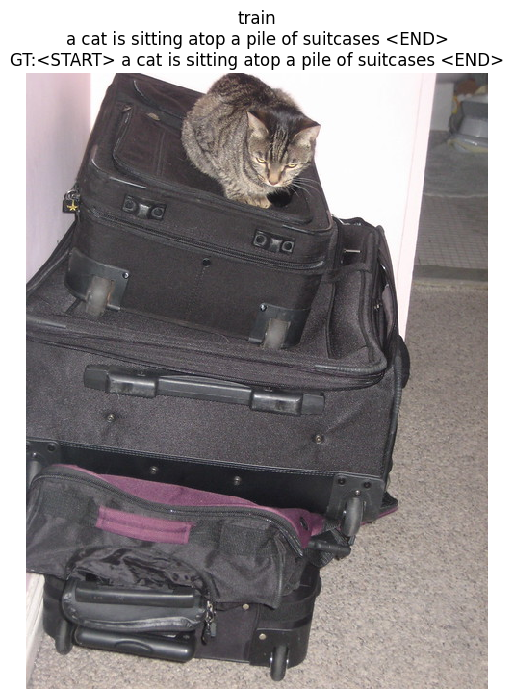

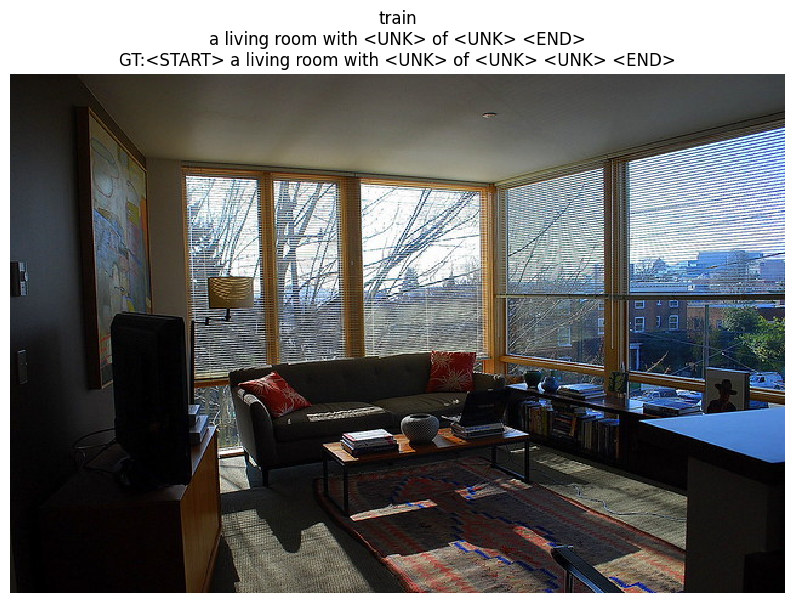

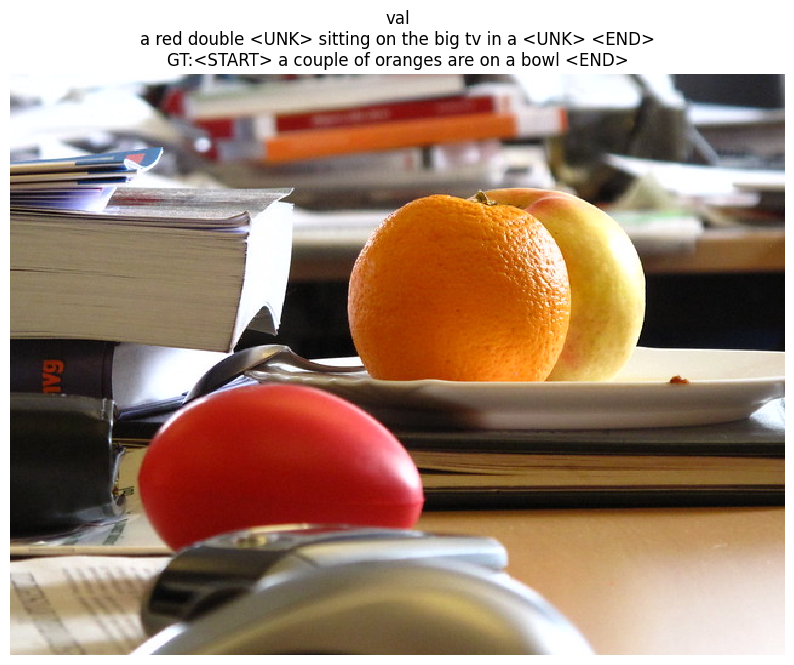

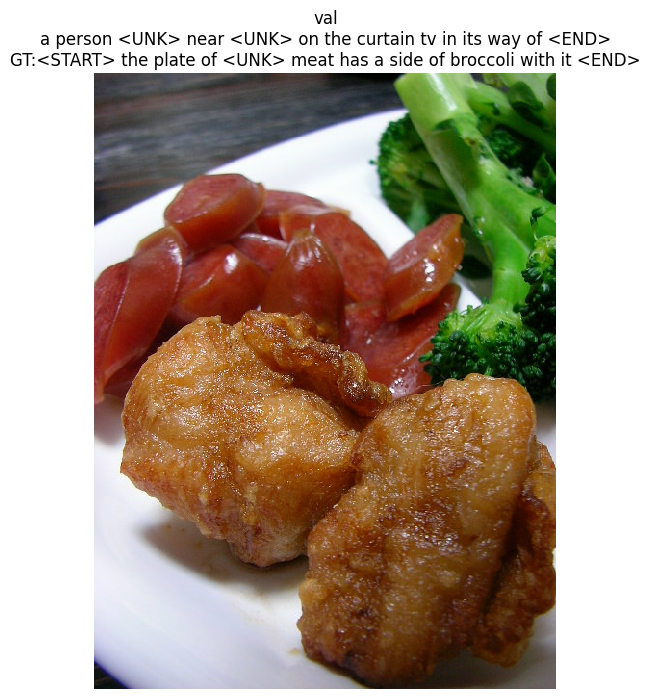

In [14]:
# 如果你遇到错误，可能是该 URL 已经不存在了，所以不用担心！
# 你可以随心所欲地重新采样多次。
for split in ['train', 'val']:
    minibatch = sample_coco_minibatch(data, split=split, batch_size=2)
    gt_captions, features, urls = minibatch
    gt_captions = decode_captions(gt_captions, data['idx_to_word'])

    sample_captions = transformer.sample(features, max_length=30)
    sample_captions = decode_captions(sample_captions, data['idx_to_word'])

    for gt_caption, sample_caption, url in zip(gt_captions, sample_captions, urls):
        img = image_from_url(url)
        # 跳过无效的 URL。
        if img is None: continue
        plt.imshow(img)
        plt.title('%s\n%s\nGT:%s' % (split, sample_caption, gt_caption))
        plt.axis('off')
        plt.show()

# 视觉 Transformer (Vision Transformer, ViT)

[Dosovitskiy 等人](https://arxiv.org/abs/2010.11929) 表明，在图像块序列上应用 transformer 模型（称为视觉 Transformer）不仅能取得令人印象深刻的性能，而且在大规模数据集上训练时，其扩展性比卷积神经网络更好。我们将使用现有的 transformer 组件实现来构建一个版本的视觉 Transformer，并在 CIFAR-10 数据集上对其进行训练。

视觉 Transformer 将输入图像转换为固定大小的图块序列，并将每个图块嵌入为隐向量 (latent vector)。在 `cs231n/transformer_layers.py` 中，完成 `PatchEmbedding` 的实现并在下方进行测试。你应该看到相对误差小于 1e-4。

In [15]:
from cs231n.transformer_layers import PatchEmbedding

torch.manual_seed(231)
np.random.seed(231)

N = 2
HW = 16
PS = 8
D = 8

patch_embedding = PatchEmbedding(
    img_size=HW,
    patch_size=PS,
    embed_dim=D
)

x = torch.randn(N, 3, HW, HW)
output = patch_embedding(x)

expected_output = np.asarray([
        [[-0.6312704 ,  0.02531429,  0.6112642 , -0.49089882,
          0.01412961, -0.6959372 , -0.32862484, -0.45402682],
        [ 0.18816411, -0.08142513, -0.9829535 , -0.23975623,
         -0.23109074,  0.97950286, -0.40997326,  0.7457837 ],
        [ 0.01810865,  0.15780598, -0.91804236,  0.36185235,
          0.8379501 ,  1.0191797 , -0.29667392,  0.20322265],
        [-0.18697818, -0.45137224, -0.40339014, -1.4381214 ,
         -0.43450755,  0.7651071 , -0.83683825, -0.16360264]],

       [[-0.39786366,  0.16201034, -0.19008337, -1.0602452 ,
         -0.28693503,  0.09791763,  0.26614824,  0.41781986],
        [ 0.35146567, -0.4469593 , -0.1841726 ,  0.45757473,
         -0.61304873, -0.29104248, -0.16124889, -0.14987172],
        [-0.2996967 ,  0.27353522, -0.09929767,  0.01973832,
         -1.2312065 , -0.6374332 , -0.22963578,  0.55696607],
        [-0.93818814,  0.02465284, -0.21117875,  1.1860403 ,
         -0.06137538, -0.21062079, -0.094347  ,  0.50032747]]])

print('error: ', rel_error(expected_output, output.detach().numpy()))

error:  5.93853582728669e-06


图块向量序列由 transformer 编码器层处理，每一层都由一个自注意力和一个前馈模块组成。由于所有向量都会相互注意（attend），因此注意力掩码并不是严格必要的。然而，为了保持一致性，我们仍然实现它。

在 `cs231n/transformer_layers.py` 中实现 `TransformerEncoderLayer`，并在下方测试它。你应该看到相对误差小于 1e-6。


In [16]:
torch.manual_seed(231)
np.random.seed(231)

from cs231n.transformer_layers import TransformerEncoderLayer

N, T, TM, D = 1, 4, 5, 12

encoder_layer = TransformerEncoderLayer(D, 2, 4*D)
encoder_layer.eval()
x = torch.randn(N, T, D)
x_mask = torch.randn(T, T) < 0.5

output = encoder_layer(x, x_mask)

expected_output = np.asarray([
    [[-0.48887438, -0.16470742,  0.7249629,  -1.0907345,   1.5764195,
       0.17484017,  0.8643941,  -0.5209561,  -1.6651545,  -1.1943513,
       1.4809005,   0.30326116],
     [-0.14663944,  1.052812,   -0.96227,    -0.20350897, -2.1478589,
       1.2637341,   0.04015125, -0.945255,    1.408903,   -0.43051198,
       0.37110543,  0.69933903],
     [ 0.08718029,  0.91050833, -1.208469,    1.1440394,  -1.9794976,
      -0.38342738, -0.47407156, -0.17345548,  0.11738186,  1.9534125,
       0.3525986,  -0.3461999],
     [-0.81389004,  0.76213264, -0.7094313,  -1.5332246,   1.3837544,
       0.4091982,   0.6569406,   0.7305365,  -1.197077,   -1.3698943,
       0.58292854,  1.0980265]]
])

print('error: ', rel_error(expected_output, output.detach().numpy()))

error:  9.230481707432173e-07


查看 `cs231n/classifiers/transformer.py` 中的 `VisionTransformer` 实现。

对于分类任务，ViT 将输入图像分成多个图块，并使用 transformer 处理图块向量序列。最后，对所有图块向量进行平均池化，并用于预测图像的类别。我们将使用相同的一维正弦位置编码来注入顺序信息，尽管二维正弦和可学习的位置编码也是有效的选择。

完成 ViT 的前向传播并在下方测试。你应该看到相对误差小于 1e-6。

In [17]:
torch.manual_seed(231)
np.random.seed(231)
from cs231n.classifiers.transformer import VisionTransformer

imgs = torch.randn(3, 3, 32, 32)
transformer = VisionTransformer()
transformer.eval()

scores = transformer(imgs)

expected_scores = np.asarray(
    [[-0.15802915,  0.15734261, -0.06002094, -0.1860142,  -0.09376919,
      -0.08837911,  0.16224845,  0.0168601,   0.20606893,  0.13079852],
     [-0.12838936,  0.20798579, -0.0620573,  -0.11705838, -0.14088857,
      -0.11387511,  0.18839046,  0.03078492,  0.17386372,  0.06414902],
     [-0.09435399,  0.20495278, -0.03362986, -0.12232997, -0.15535004,
      -0.10380758,  0.21114832,  0.03481449,  0.18798208,  0.12231653]])

print('scores error: ', rel_error(expected_scores, scores.detach().numpy()))

scores error:  8.140228498347053e-07



我们首先将通过在一个训练批次上过拟合来验证我们的实现。相应地调整学习率和权重衰减。

In [21]:
from torchvision import transforms
from torchvision.datasets import CIFAR10
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

train_data = CIFAR10(root='cs231n/datasets', train=True, transform=transforms.ToTensor(), download=False)
test_data = CIFAR10(root='cs231n/datasets', train=False, transform=transforms.ToTensor(), download=False)

In [26]:

learning_rate = 1e-3   # 尝试调整这个值
weight_decay = 0.0  # 尝试调整这个值


batch = next(iter(DataLoader(train_data, batch_size=64, shuffle=False)))
model = VisionTransformer(dropout=0.0)
loss_criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
model.train()

epochs = 100
for epoch in range(epochs):
    imgs, target = batch
    out = model(imgs)
    loss = loss_criterion(out, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    top1 = (out.argmax(-1) == target).float().mean().item()
    if epoch % 10 == 0:
      print(f"[{epoch}/{epochs}] Loss {loss.item():.6f}, Top-1 Accuracy: {top1:.3f}")


[0/100] Loss 2.301847, Top-1 Accuracy: 0.188
[10/100] Loss 2.081409, Top-1 Accuracy: 0.219
[20/100] Loss 1.880940, Top-1 Accuracy: 0.281
[30/100] Loss 1.623399, Top-1 Accuracy: 0.359
[40/100] Loss 1.241947, Top-1 Accuracy: 0.578
[50/100] Loss 0.756209, Top-1 Accuracy: 0.781
[60/100] Loss 0.460601, Top-1 Accuracy: 0.875
[70/100] Loss 0.174415, Top-1 Accuracy: 0.984
[80/100] Loss 0.052613, Top-1 Accuracy: 1.000
[90/100] Loss 0.023255, Top-1 Accuracy: 1.000


In [27]:
# 你应该获得完美的 1.00 准确率
print(f"Overfitting ViT on one batch. Top-1 accuracy: {top1}")

Overfitting ViT on one batch. Top-1 accuracy: 1.0


现在我们将要在整个数据集上训练它。

In [28]:
from cs231n.classification_solver_vit import ClassificationSolverViT

############################################################################
# TODO: 训练一个 Vision Transformer 模型，使其在 2 个 epoch 后            #
# 在 CIFAR-10 上的测试准确率超过 0.45，方法是根据需要调整模型架构          #
# 和/或训练参数。                                                          #
#                                                                          #
# 注意：如果你想使用 GPU 运行时，请转到 `代码执行程序 > 更改运行时类型`     #
# 并将 `硬件加速器` 设置为 `GPU`。这会重置 Colab，                          #
# 因此请确保之后从头重新运行整个 notebook。                                #
############################################################################


learning_rate = 1e-4
weight_decay = 0.0
batch_size = 64
model = VisionTransformer()  # 你可能需要更改默认参数。




################################################################################
#                                 END OF YOUR CODE                             #
################################################################################

solver = ClassificationSolverViT(
    train_data=train_data,
    test_data=test_data,
    model=model,
    num_epochs = 2,  # 不要更改这个 epoch 值
    learning_rate = learning_rate,
    weight_decay = weight_decay,
    batch_size = batch_size,
)

solver.train('cuda' if torch.cuda.is_available() else 'cpu')



  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

In [29]:
print(f"Accuracy on test set: {solver.results['best_test_acc']}")

Accuracy on test set: 0.4003


# 内联问题 2

尽管近期在大型图像识别任务上取得了成功，但在较小的数据集上训练时，ViT 往往落后于传统的 CNN。哪些潜在因素导致了这种性能差距？可以使用什么技术来提高 ViT 在小数据集上的性能？

**你的回答**：
CNN的卷积核在扫描图像的时候，预设了认为相邻的像素是相关的这个概念，ViT则把图像视为一个个patch串起来，在一开始没有关于图像结构的信息，因此在样本数量少的时候效果没有CNN好。
1.可以先用CNN训练一个模型，利用输出作为标签去指导ViT训练。
2.可以使用卷积层来代替patch embedding。
3.用大数据集先预训练一个ViT，再用小数据集进行微调。

# 内联问题 3

如果我们独立进行以下更改，ViT 中自注意力层的计算成本会如何变化？请忽略 QKV 和输出投影的计算成本。

(i) 隐藏层维度加倍。
(ii) 输入图像的高度和宽度加倍。
(iii) 图块大小加倍。
(iv) 层数加倍。

**你的回答**：
1.变成原来的2倍
2.变成原来的16倍 
3.变成原来的1/16
4.变成原来的两倍
